<!-- [![Notebook Tutorial](__code/__all/notebook_tutorial.png)](https://neutronimaging.ornl.gov/cylindrical-geometry-correction-for_white_beam_data/) -->

<img src='__docs/__all/notebook_rules.png' />

# Select your IPTS

In [1]:
# %matplotlib notebook

import warnings
warnings.filterwarnings('ignore')

from __code.cylindrical_geometry_correction_embedded_widgets.main import CylindricalGeometryCorrectionEmbeddedWidgets

from __code import system
system.System.select_working_dir(notebook='cylindrical_geometry_correction_embedded_widgets', ipts="IPTS-26647", instrument="CG1D")

from __code.__all import custom_style
custom_style.style()

# <font color=red>Select normalized images</font>

In [2]:
o_correction = CylindricalGeometryCorrectionEmbeddedWidgets(working_dir=system.System.get_working_dir(), debug=True)
o_correction.select_images()

Output()

Output()

Loading sample:   0%|          | 0/2 [00:00<?, ?it/s]

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='purple' size='5'>Use config file</font><font color='purple' size='3'> - OPTIONAL</font>

Run this cell when you have a config file you saved in a previous session and wants to reload it here. This will allow you to automatically re-use the same region of interests. 

In [3]:
o_correction.select_config()

Output()

Output()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='purple' size='5'>Visualize data</font><font color='purple' size='3'> - OPTIONAL</font>

In [4]:
o_correction.visualize_raw_images()

interactive(children=(IntSlider(value=0, description='image_index', layout=Layout(width='50%'), max=1, style=S…

<hr style="border-bottom: dotted 1px;" />
<hr style="height: 2px" />

# <font color=red>Rotate sample to make sure it's perfectly vertical</font>

Use the **vertical guide** to help you find the perfect vertical to your sample.

Feel free to use the **green** and **blue** horizontal profiles helper to make sure the sample is perfectly vertical. To do so, place one of the two profile helper near the top of the sampel and the other one, near the bottom and make sure the edge is perfectly aligned top to bottom.

<img src='__code/cylindrical_geometry_correction_embedded_widgets/static/example_rotation_guides.png' width="50%"/>

In [5]:
o_correction.rotate_images()

interactive(children=(Checkbox(value=False, description='Rotate 90 deg'), FloatSlider(value=0.3, continuous_up…

# <font color='red'>Crop sample to region of interest</font>

By playing with the **left**, **right**, **top** and **bottom** sliders, select a region surrounding the data you want to work with.

Use the **profile marker** to make sure the sample is within the boundaries defined. Leave some **marging on either side** as the program will be able to calculate and locate the edges of the sample for you. 

<img src='__code/cylindrical_geometry_correction_embedded_widgets/static/example_crop_region.png' width="50%" />

In [6]:
o_correction.apply_rotation()
o_correction.select_crop_region()

interactive(children=(IntSlider(value=10, description='fig_size', layout=Layout(width='50%'), max=20, min=5, s…

In [7]:
o_correction.checking_edges()

interactive(children=(IntSlider(value=0, description='image_index', layout=Layout(width='50%'), max=1), Output…

Perform the cropping

In [8]:
o_correction.crop_images()

<hr style="height: 2px" /><hr style="border-bottom: dotted 1px" />
<font color='purple' size='5'>Export cropped images</font><font color='purple' size='3'> - OPTIONAL</font>

In [9]:
# o_correction.export_cropped_images()

<hr style="border-bottom: dotted 1px;" />
<hr style="height: 2px" />

# <font color='red'>Detection of edges - calculation chord length map</font>


In [10]:
o_correction.visualize_or_not_results()

ToggleButtons(options=('Yes', 'No'), value='Yes')

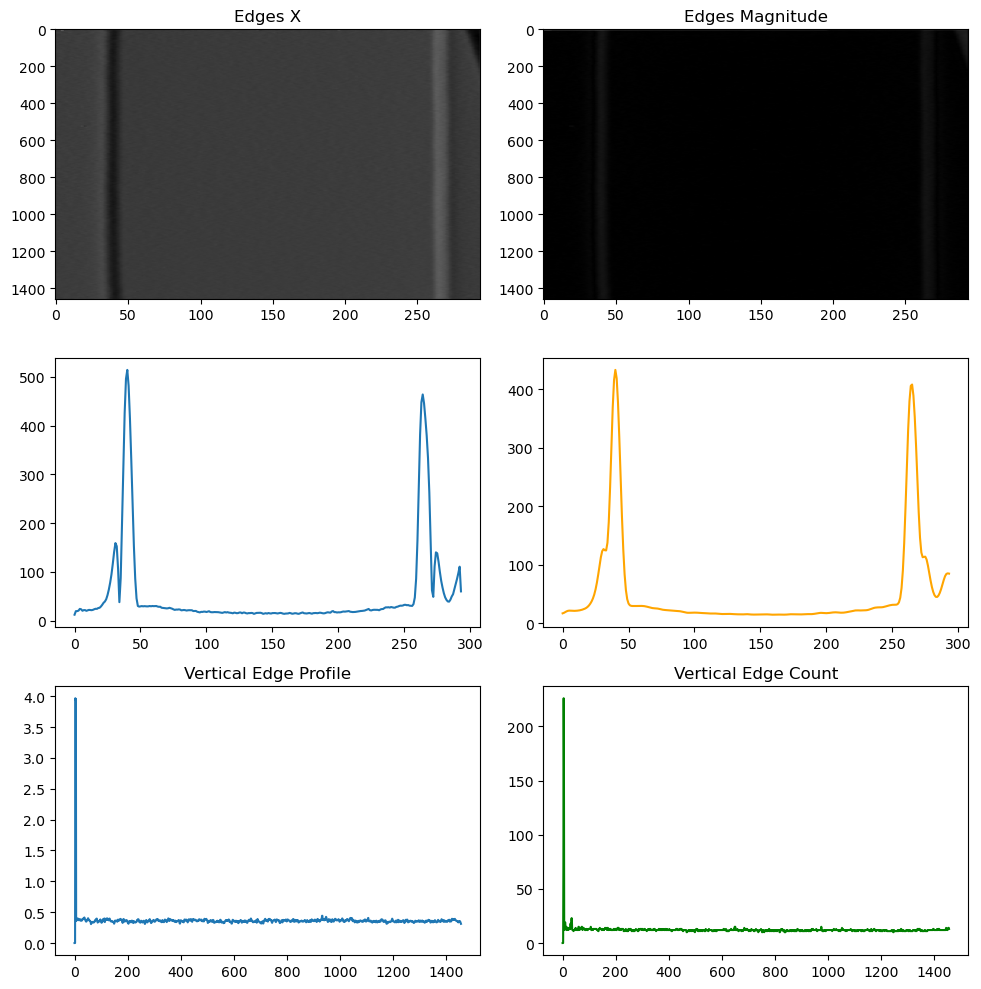

In [12]:
o_correction.calculate_and_visualize_edges()

## Cylindrical Geometry Correction

Transmission data in neutron imaging follow the Beer–Lambert law:

$$
T(x,\lambda) = \frac{I(x,\lambda)}{I_0(x,\lambda)} = e^{-\mu(\lambda)\,L(x)}
$$

where:  
- $T(x,\lambda)$ = transmission at column $x$ and wavelength $\lambda$  
- $\mu(\lambda)$ = wavelength-dependent attenuation coefficient  
- $L(x)$ = chord length through the cylinder at $x$

Because open-beam normalization is often imperfect, $T(x,\lambda)$ can exceed 1 ⚠️.  
To estimate $\mu(\lambda)$ robustly, we use two strategies:

- **Discrete Method (Two-Column):**  
  Select two positions $x_1, x_2$. Then  
  $$
  \mu(\lambda) = -\frac{1}{L(x_2)-L(x_1)} \ln\!\left(\frac{T(x_1,\lambda)}{T(x_2,\lambda)}\right)
  $$  
  Relies on relative differences, making it less sensitive to open-beam errors. 
  
- **Iterative Method (Global Fit):**  
  Fit all columns simultaneously:  
  $$
  -\ln T(x,\lambda) \approx \mu(\lambda)\,L(x) + b(x)
  $$  
  where $b(x)$ accounts for slow background variation.  
  This provides a stable global estimate of $\mu(\lambda)$.

Once $\mu(\lambda)$ is known, we correct the data to a uniform thickness equal to the cylinder diameter $D$:

$$
C(x,\lambda) = e^{-\mu(\lambda)\,(D-L(x))}, \quad 
T^D(x,\lambda) = T(x,\lambda)\,C(x,\lambda)
$$

This correction flattens the cylindrical modulation, producing transmission as if the sample had uniform thickness $D$.

# <font color='red'>Applying geometry correction</font>

In [ ]:
o_ipts.correct_cylinder_geometry()

# <font color='red'>Export</font>

This will export:
 - the corrected cropped images
 - the full horizontal profiles of each image
 - all the configuration used in this notebook (config file)

In [ ]:
o_ipts.export_profiles()